# Retail Sales and Profitability

**Author: Tajamul Khan**

Which categories generate revenue without healthy margins?

Original synthetic teaching data. All outputs below are calculated by executing these cells. This is an analytical portfolio case study, not a real client engagement.

## Situation and task

A retailer sees growing sales but cannot tell whether discounts are eroding contribution.

Reconcile net sales and contribution across categories, regions and months.

## Data contract and KPI definitions

One row per order line; net_sales = quantity × price × (1 − discount) × (1 − returned); contribution subtracts retained-item cost; margin = sum(contribution) / sum(net_sales). Full returns have zero revenue and recover all inventory cost; reverse logistics is excluded.

See `data/README.md` for field types, source and seed.

In [1]:
from pathlib import Path
import json, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
BASE = Path.cwd()
assert (BASE/'data/raw.csv').exists(), 'Run from this project directory'
OUT = BASE/'outputs'
OUT.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
df = pd.read_csv(BASE/'data/raw.csv')
if 'date' in df:
    df['date'] = pd.to_datetime(df['date'])
print('Raw shape:',df.shape)
display(df.head())


Raw shape: (6012, 9)


,line_id,date,category,region,quantity,unit_price,discount,returned,unit_cost
0,1,2025-01-12,Home,East,4,126.47,0.00,0,69.98
1,2,2025-08-07,Electronics,East,4,201.62,0.05,0,91.42
2,3,2025-02-13,Grocery,South,4,94.10,0.05,0,46.37
3,4,2025-08-02,Electronics,West,1,93.95,0.00,0,58.49
4,5,2025-05-30,Clothing,West,2,157.01,0.05,0,81.86


## Validate the source

Inspect missingness and grain before computing metrics. Missing outcomes are not automatically zeros.

In [2]:
audit=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum(),'unique_values':df.nunique()})
display(audit)
print('Exact duplicate rows:',df.duplicated().sum())
audit.to_csv(OUT/'data_quality.csv')


Exact duplicate rows: 12


,dtype,missing,unique_values
line_id,int64,0,6000
date,datetime64[ns],0,365
category,object,0,4
region,object,0,4
quantity,int64,0,5
unit_price,float64,0,5305
discount,float64,0,4
returned,int64,0,2
unit_cost,float64,0,5031


## Action: analysis

Deduplicate order lines, calculate net sales after discounts and returns, compare weighted contribution margins and reconcile SQL to Python.

In [3]:
df=df.drop_duplicates('line_id').copy()
assert df.line_id.is_unique and df.quantity.gt(0).all()
df['net_sales']=df.quantity*df.unit_price*(1-df.discount)*(1-df.returned)
df['contribution']=df.net_sales-df.quantity*df.unit_cost*(1-df.returned)
summary=df.groupby('category').agg(net_sales=('net_sales','sum'),contribution=('contribution','sum'),lines=('line_id','size'))
summary['margin_pct']=100*summary.contribution/summary.net_sales
monthly=df.groupby(df.date.dt.to_period('M').astype(str)).net_sales.sum()
metrics={'Net sales (USD)':df.net_sales.sum(),'Contribution margin (%)':100*df.contribution.sum()/df.net_sales.sum(),'Return rate (%)':100*df.returned.mean()}
chart=summary.net_sales; ylabel='Net sales (USD)'
extra=monthly.rename('net_sales').to_frame(); extra.to_csv(OUT/'monthly_sales.csv')

## Deep dive: Discount bands and contribution

Compare weighted contribution margins at each discount level. This is descriptive; category mix and customer selection can confound the comparison.

The 30% discount band has the lowest observed contribution margin (7.33%). Investigate category mix before changing discount policy.
Out[4]: 133


,net_sales,contribution,lines,margin_pct
discount,,,,
0.00,552697.850,192781.440,1494,34.880
0.05,511556.988,161478.338,1435,31.566
0.15,458506.940,106408.710,1479,23.208
0.30,401374.554,29404.484,1592,7.326


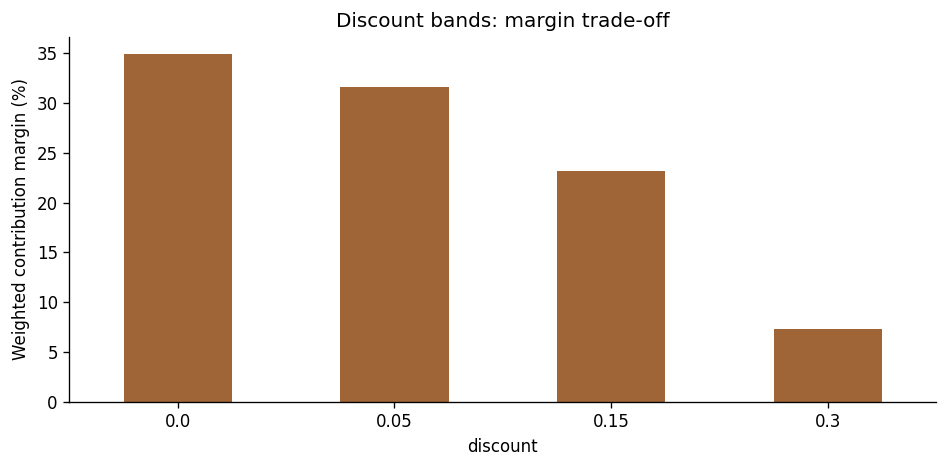

In [4]:

detail=df.groupby('discount').agg(net_sales=('net_sales','sum'),contribution=('contribution','sum'),lines=('line_id','size'))
detail['margin_pct']=100*detail.contribution/detail.net_sales
display(detail.round(3))
fig,ax=plt.subplots(figsize=(8,4));detail.margin_pct.plot.bar(ax=ax,color='#a06536',rot=0);ax.set_ylabel('Weighted contribution margin (%)');ax.set_title('Discount bands: margin trade-off');fig.tight_layout();fig.savefig(OUT/'detail.png');plt.show()
lowest=detail.margin_pct.idxmin()
recommendation=f'The {lowest:.0%} discount band has the lowest observed contribution margin ({detail.loc[lowest,"margin_pct"]:.2f}%). Investigate category mix before changing discount policy.'

detail.to_csv(OUT/'detail.csv')
print(recommendation)
(OUT/'recommendation.txt').write_text(recommendation+'\n')


## Results: calculated evidence

These describe only the included synthetic dataset. They do not measure deployed impact.

In [5]:
display(summary.round(4))
display(pd.Series(metrics,name='value').to_frame())
summary.to_csv(OUT/'summary.csv')
(OUT/'metrics.json').write_text(json.dumps({k:float(v) for k,v in metrics.items()},indent=2))
df.to_csv(OUT/'analysis_ready.csv',index=False)
assert all(np.isfinite(float(v)) for v in metrics.values()), 'Invalid KPI'


,net_sales,contribution,lines,margin_pct
category,,,,
Clothing,468313.7590,119051.9990,1471,25.4214
Electronics,485567.9465,119570.8565,1531,24.6249
Grocery,476375.4940,119347.6140,1501,25.0533
Home,493879.1330,132102.5030,1497,26.7479


,value
Net sales (USD),1.924136e+06
Contribution margin (%),2.546976e+01
Return rate (%),7.316667e+00


## SQL cross-check

Load validated facts into SQLite and reconcile shared aggregates against Python.

In [6]:
with sqlite3.connect(':memory:') as conn:
    df.to_sql('facts',conn,index=False,if_exists='replace')
    sql_result=pd.read_sql_query((BASE/'analysis.sql').read_text(),conn)
display(sql_result)
sql_result.to_csv(OUT/'sql_results.csv',index=False)
# Reconcile at least one common aggregate by group, rather than trusting the SQL output.
key=sql_result.columns[0]
py=summary.reset_index()
common=[c for c in sql_result.columns[1:] if c in py.columns]
assert common, 'No comparable aggregate'
joined=sql_result.merge(py,on=key,suffixes=('_sql','_python'),validate='one_to_one')
assert len(joined)==len(summary)==len(sql_result)
for col in common:
    assert np.allclose(joined[col+'_sql'],joined[col+'_python'],rtol=1e-8,atol=1e-6), col
print('SQL / Python reconciliation passed:',common)


SQL / Python reconciliation passed: ['net_sales', 'contribution']


,category,net_sales,contribution
0,Home,493879.1330,132102.5030
1,Electronics,485567.9465,119570.8565
2,Grocery,476375.4940,119347.6140
3,Clothing,468313.7590,119051.9990


## Visual interpretation

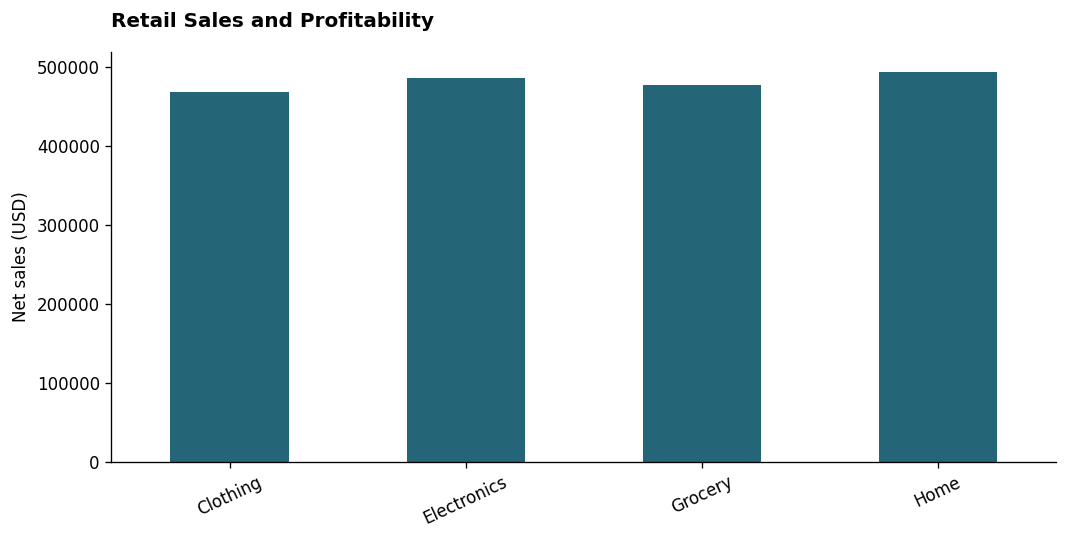

In [7]:
fig,ax=plt.subplots(figsize=(9,4.6))
chart.plot(kind='bar',ax=ax,color='#246577',rot=25)
ax.set_ylabel(ylabel)
ax.set_xlabel('')
ax.set_title('Retail Sales and Profitability',loc='left',fontweight='bold',pad=15)
fig.tight_layout()
fig.savefig(OUT/'overview.png',bbox_inches='tight')
plt.show()


## Offline dashboard

The KPI cards and chart are a fixed analysis snapshot. The row filter searches the summary table; it does not recompute the KPIs.

In [8]:
# Standalone dashboard: no remote JavaScript, server or account required.
import html, base64
cards=''.join('<article><span>'+html.escape(k)+'</span><strong>'+f'{v:,.4f}'+'</strong></article>' for k,v in metrics.items())
image=base64.b64encode((OUT/'overview.png').read_bytes()).decode()
table=summary.round(4).to_html(classes='data',border=0)
page='''<!doctype html><html lang="en"><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1"><title>Retail Sales and Profitability</title>
<style>body{font:16px system-ui;margin:0;background:#f3f5f7;color:#172c3b}main{max-width:1100px;margin:auto;padding:36px}header{border-bottom:3px solid #246577;margin-bottom:24px}small{color:#51616c}.cards{display:flex;gap:14px;flex-wrap:wrap}article{background:white;padding:18px;border:1px solid #d7e0e5;flex:1;min-width:175px}strong{display:block;font-size:27px;margin-top:12px}img{max-width:100%;margin-top:24px}table{border-collapse:collapse;background:white;width:100%;font-size:14px}td,th{padding:12px;text-align:right;border-bottom:1px solid #d7e0e5}input{padding:12px;margin:20px 0;width:280px;max-width:90%}.scroll{overflow:auto}footer{margin-top:24px}</style>
<main><header><small>TAJAMUL KHAN · DATA ANALYST PORTFOLIO</small><h1>Retail Sales and Profitability</h1><p>Which categories generate revenue without healthy margins?</p><p><b>Synthetic teaching data · Fictional 2025 case study</b></p></header><section class="cards">'''+cards+'''</section><img alt="Analysis overview chart" src="data:image/png;base64,'''+image+'''"><h2>Explore summary groups</h2><label for="filter">Filter summary rows</label><br><input id="filter" placeholder="Type a group name"><div class="scroll">'''+table+'''</div><p>Contribution excludes fixed overhead and tax. Discount comparisons are observational and do not establish causation.</p><footer>Instagram @tajamul.codes · linkedin.com/in/tajamulkhann/</footer></main>
<script>document.getElementById('filter').addEventListener('input',function(){const q=this.value.toLowerCase();document.querySelectorAll('tbody tr').forEach(r=>r.hidden=!r.textContent.toLowerCase().includes(q))});</script></html>'''
detail_image=base64.b64encode((OUT/'detail.png').read_bytes()).decode()
page=page.replace('<h2>Explore summary groups</h2>','<h2>Analyst finding</h2><p>'+html.escape(recommendation)+'</p><img alt="Supporting analysis" src="data:image/png;base64,'+detail_image+'"><h2>Explore summary groups</h2>')
(OUT/'dashboard.html').write_text(page)
print('Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.')


Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.


## Decision, limitations and next step

Contribution excludes fixed overhead and tax. Discount comparisons are observational and do not establish causation.

**Next step:** Join actual campaign assignments and test a discount policy on a randomized holdout.

Use the result table to identify a priority for investigation. Avoid claiming that the suggested action has already delivered a business improvement.

## Career discussion

Explain the business question, data grain, denominator, validation, strongest finding and one limitation. Use the README STAR story only after reproducing and understanding this project.